# SABR Cap & Floor Surface Calibration & Pricing

## Contexte et objectifs

Ce notebook implémente un **pipeline complet de calibration et de pricing de caps et floors** fondé sur le modèle SABR (*Stochastic Alpha Beta Rho*) de Hagan, Kumar, Léger & Woodward (2002). Les caps et floors sont les dérivés de taux les plus liquides sur les taux courts ; leur surface de volatilité implicite constitue l'entrée essentielle de tout desk de taux pour le marking et la gestion des risques.

### Rappel : le contrat cap / floor

Un **cap** donne à son détenteur le droit de recevoir le différentiel positif entre le taux LIBOR et un strike $K$ sur chaque période. Son payoff agrégé est :

$$V_{\text{cap}} = \sum_{i=1}^{n} N \cdot \delta_i \cdot P(0,T_i) \cdot \max(F_i - K,\; 0)$$

où $F_i$ est le taux forward LIBOR sur la période $[T_{i-1}, T_i]$, $\delta_i$ la longueur de la période et $P(0,T_i)$ le facteur d'actualisation. Un **floor** inverse la direction du payoff : $\max(K - F_i, 0)$.

**Parité fondamentale (absence d'arbitrage) :**
$$\text{Cap}(K) - \text{Floor}(K) = \text{PV(Swap payeur } K\text{)}$$

Les floors sont déduits par parité depuis les caps et la courbe OIS — une seule surface de vol suffit.

### Structure du pipeline

| Étape | Objet | Module |
|-------|-------|--------|
| 1 | Bootstrap de la courbe OIS | `yield_curve.py` |
| 2 | Lecture surface vol caps USD | `data_loader.py` |
| 3 | Calibration SABR slice par slice | `sabr.py` |
| 4 | Pricing Black-76 + Greeks analytiques | `pricer.py` |
| 5 | Analyses : smiles, terme structure, β | `plot_utils.py` |

### Données

| Fichier | Contenu | Nature |
|---------|---------|--------|
| `usdois.xlsx` | Courbe discount USD OIS — 25 piliers 2016→2046 | **Vraie donnée marché** |
| `cap_vol_surface.xlsx` | Surface vol caps USD — 120 expiries × 19 strikes | **Vraie donnée marché** |

Les taux forward LIBOR sont **bootstrappés depuis l'OIS** (relation d'arbitrage exacte — pas synthétiques).


In [1]:
# ── Paramètres ────────────────────────────────────────────────────────────────
from pathlib import Path
BASE_DIR  = Path().resolve()                        # dossier courant du notebook
OIS_PATH  = BASE_DIR / "data" / "usdois.xlsx"       # courbe discount factors
VOL_PATH  = BASE_DIR / "data" / "cap_vol_surface.xlsx"  # surface vol caps
BETA      = 0.0    # exposant CEV — 0=normal (Bachelier), optimal pour USD 2016
RESTARTS  = 5      # restarts aléatoires par slice
SHIFT     = 0.01   # décalage Shifted SABR (1% standard marché USD 2016)
DELTA     = 0.5    # fréquence des caplets (6M)
K_MIN     = 0.005  # borne inférieure zone liquide de calibration
K_MAX     = 0.06   # borne supérieure zone liquide de calibration


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

warnings.filterwarnings('ignore', category=RuntimeWarning)

from data_loader import load_discount_factors, load_cap_vol_surface, load_calibration_smiles
from yield_curve  import YieldCurve
from sabr         import calibrate_surface, sabr_vol_vec, SABRCapSurface
from pricer       import black_caplet, cap_price, floor_price, cap_greeks
from plot_utils   import (
    plot_yield_curve,
    plot_vol_surface_overview,
    plot_sabr_params_term_structure,
    plot_all_smiles,
    plot_rmse,
    plot_individual_smile,
    plot_price_vega_smile,
    plot_parity_verification,
    plot_beta_comparison,
)


## 1. Construction de la courbe des taux

### Interpolation log-linéaire des facteurs d'actualisation

À partir des prix de marché $P(0, T_i)$ observés sur les 25 piliers de la courbe OIS USD, on reconstruit une courbe continue par **interpolation log-linéaire** :

$$\ln P(0, T) = \ln P(0, T_i) + \frac{T - T_i}{T_{i+1} - T_i}\bigl[\ln P(0, T_{i+1}) - \ln P(0, T_i)\bigr]$$

### Taux forward LIBOR 6M — bootstrapping

Le taux forward LIBOR entre $T_1$ et $T_2$ est déduit par **relation d'arbitrage exacte** :

$$F(T_1, T_2) = \frac{P(0, T_1)}{P(0, T_2) \cdot (T_2 - T_1)} - \frac{1}{T_2 - T_1}$$

Ces forwards ne sont **pas synthétiques** — ils sont une conséquence directe des vrais prix OIS observés.


In [3]:
df_raw = load_discount_factors(OIS_PATH)
yc     = YieldCurve(df_raw)

print(f"Date de référence : {yc.ref_date.date()}")
print(f"Nombre de piliers  : {len(df_raw)}")
print(f"Maturité min/max   : {yc._T[1]:.2f}y – {yc._T[-1]:.1f}y")


Date de référence : 2016-07-13
Nombre de piliers  : 25
Maturité min/max   : 0.00y – 30.0y


In [4]:
print("Piliers de la courbe :")
print(yc.pillar_summary().to_string(index=False))


Piliers de la courbe :
 T (ans)   P(0,T)  Taux zero (%)
  0.0000 1.000000            inf
  0.0027 0.999988         0.4512
  0.0055 0.999975         0.4588
  0.0356 0.999871         0.3627
  0.0959 0.999624         0.3924
  0.1863 0.999277         0.3885
  0.2685 0.998960         0.3876
  0.5205 0.997979         0.3887
  0.7671 0.996940         0.3995
  1.0164 0.995859         0.4082
  1.5178 0.993495         0.4300
  2.0137 0.991000         0.4490
  3.0110 0.985024         0.5012
  4.0137 0.978132         0.5509
  5.0192 0.969832         0.6103
  6.0192 0.959957         0.6789
  7.0192 0.948891         0.7474
  8.0164 0.936871         0.8135
  9.0164 0.924257         0.8736
 10.0164 0.911262         0.9277
 12.0247 0.882973         1.0350
 15.0192 0.841402         1.1498
 20.0247 0.774695         1.2749
 25.0274 0.715401         1.3382
 30.0329 0.663330         1.3668


In [5]:
print("Taux forward LIBOR 6M bootstrappés (exemples) :")
for T1, T2 in [(0,0.5),(0.5,1),(1,1.5),(2,2.5),(5,5.5),(9.5,10)]:
    f = yc.forward_rate(T1, T2)
    print(f"  F({T1:.1f}Y, {T2:.1f}Y) = {f:.4%}")


Taux forward LIBOR 6M bootstrappés (exemples) :
  F(0.0Y, 0.5Y) = 0.3890%
  F(0.5Y, 1.0Y) = 0.4274%
  F(1.0Y, 1.5Y) = 0.4734%
  F(2.0Y, 2.5Y) = 0.6047%
  F(5.0Y, 5.5Y) = 1.0193%
  F(9.5Y, 10.0Y) = 1.4210%


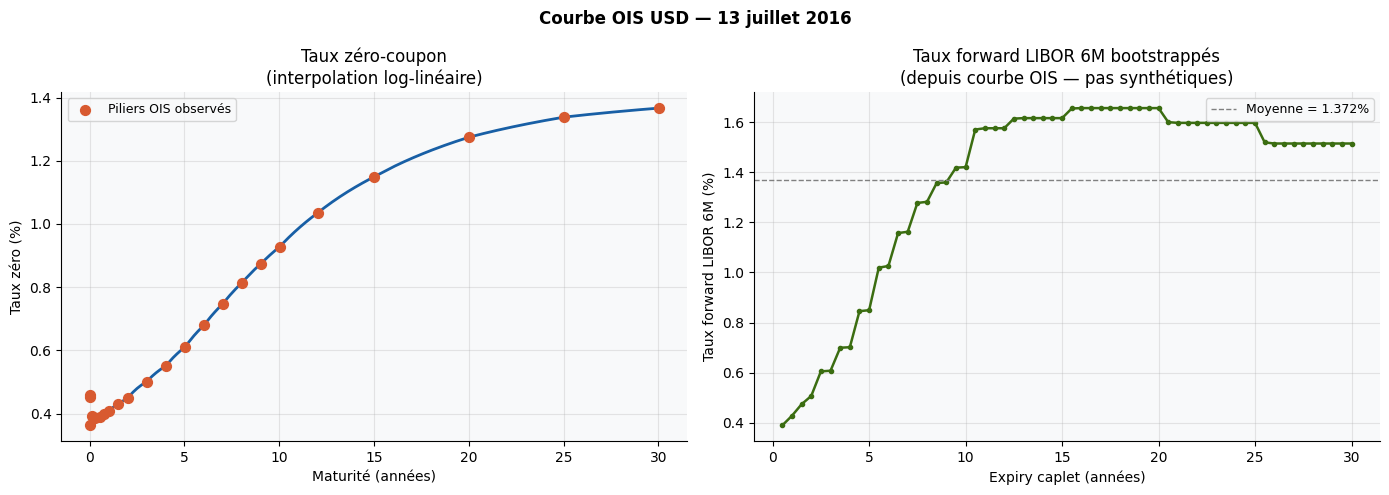

In [6]:
plot_yield_curve(yc)


## 2. Chargement de la surface de volatilité de marché

### Structure des cotations caps

La surface de vol caps couvre une grille de **120 expiries × 19 strikes** (0.25% à 11%). Pour chaque expiry, on dispose de la volatilité implicite log-normale (Black) à chaque strike.

**Convention de marché :** les expiries 3M–1Y ont des vols identiques ; le premier caplet liquide démarre à 1Y sur le marché USD 2016.

**Zone de calibration :** on retient les strikes entre 0.5% et 6% — zone liquide, excluant les ailes extrêmes non reproductibles par SABR standard (smile fortement asymétrique typique du régime de taux bas USD 2016).


In [7]:
vol_surface_tidy = load_cap_vol_surface(VOL_PATH)
df_vol_raw       = pd.read_excel(VOL_PATH, index_col=0)
strikes_all      = [float(c)/100 for c in df_vol_raw.columns]

print(f"Expiries disponibles : {df_vol_raw.shape[0]}")
print(f"Strikes disponibles  : {df_vol_raw.shape[1]}  ({min(strikes_all)*100:.2f}% – {max(strikes_all)*100:.1f}%)")
print(f"Total de quotes      : {len(vol_surface_tidy)}")
vol_surface_tidy.head(10)


Expiries disponibles : 120
Strikes disponibles  : 19  (0.25% – 11.0%)
Total de quotes      : 2280


,expiry,level_1,implied_vol
0,3M,0.0025,0.7461
1,3M,0.0050,0.5496
2,3M,0.0075,0.4665
3,3M,0.0100,0.4865
4,3M,0.0125,0.5293
5,3M,0.0150,0.5704
6,3M,0.0200,0.6420
7,3M,0.0250,0.6988
8,3M,0.0300,0.7431
9,3M,0.0350,0.7787


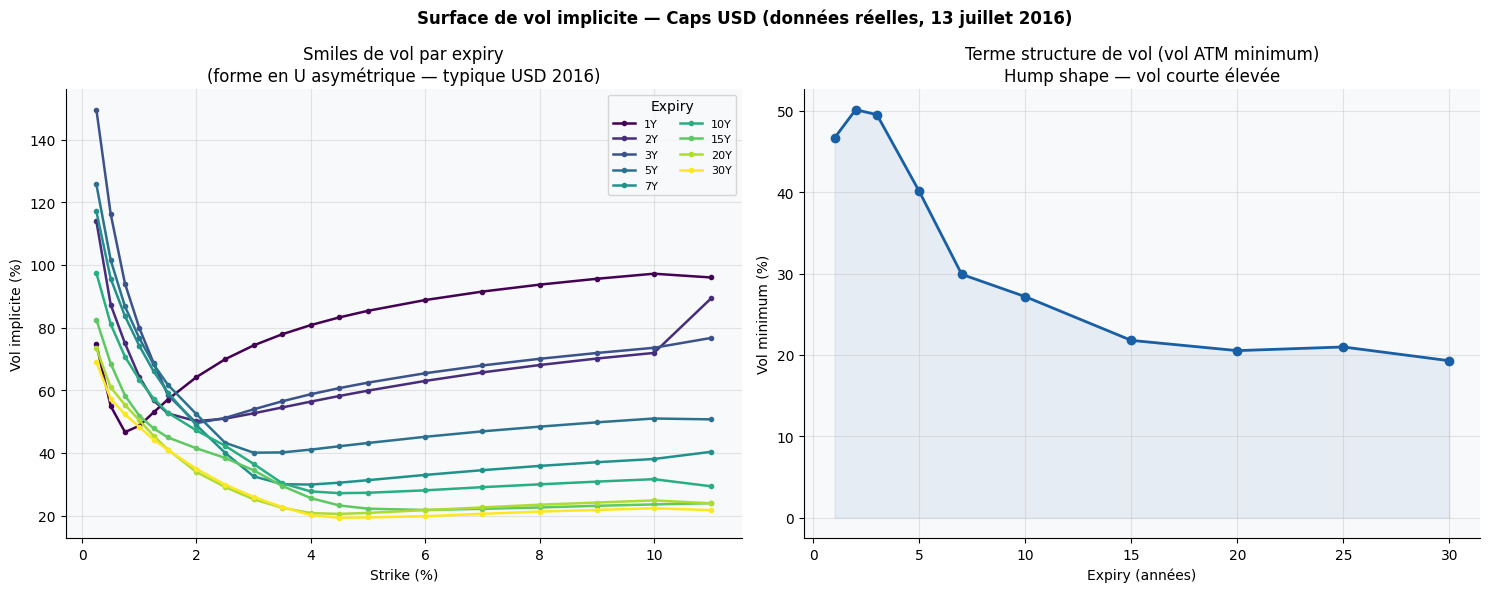

In [8]:
plot_vol_surface_overview(df_vol_raw, strikes_all)


### Analyse de la smile — forme asymétrique

La smile USD 2016 présente une **forme en U fortement asymétrique** :
- Vol très haute pour les bas strikes (floors deep ITM) : le marché intègre une prime de protection contre une remontée brutale des taux post-GFC
- Vol plus modérée pour les hauts strikes (caps OTM) : la Fed s'est engagée sur une normalisation graduelle

Cette asymétrie est une **limite connue du SABR standard** — le modèle calibre bien la zone ATM mais ne peut pas reproduire parfaitement les ailes extrêmes.


In [9]:
# Analyse détaillée de la smile 5Y
print("Smile 5Y — structure de la volatilité :")
print(f"{'Strike':>8}  {'Vol (%)':>8}  Commentaire")
print("-"*50)
for K_str, v in zip(df_vol_raw.columns, df_vol_raw.loc['5Y'].values):
    K = float(K_str)/100
    if K < 0.01:   comment = "← floor deep ITM (très haute)"
    elif K < 0.03: comment = "← zone OTM floor"
    elif K < 0.04: comment = "← zone ATM (vol minimale)"
    elif K < 0.06: comment = "← zone calibrée"
    else:          comment = "← hors zone liquide"
    print(f"  {K*100:>5.2f}%  {v:>8.2f}%  {comment}")


Smile 5Y — structure de la volatilité :
  Strike   Vol (%)  Commentaire
--------------------------------------------------
   0.25%    125.66%  ← floor deep ITM (très haute)
   0.50%    101.53%  ← floor deep ITM (très haute)
   0.75%     86.72%  ← floor deep ITM (très haute)
   1.00%     76.65%  ← zone OTM floor
   1.25%     68.23%  ← zone OTM floor
   1.50%     61.74%  ← zone OTM floor
   2.00%     52.34%  ← zone OTM floor
   2.50%     43.25%  ← zone OTM floor
   3.00%     40.08%  ← zone ATM (vol minimale)
   3.50%     40.16%  ← zone ATM (vol minimale)
   4.00%     41.06%  ← zone calibrée
   4.50%     42.13%  ← zone calibrée
   5.00%     43.17%  ← zone calibrée
   6.00%     45.14%  ← hors zone liquide
   7.00%     46.88%  ← hors zone liquide
   8.00%     48.38%  ← hors zone liquide
   9.00%     49.76%  ← hors zone liquide
  10.00%     50.98%  ← hors zone liquide
  11.00%     50.70%  ← hors zone liquide


## 3. Calibration SABR (Hagan et al., 2002)

### Dynamique SABR

Le modèle SABR décrit l'évolution du taux forward $F_t$ et de sa volatilité stochastique $\alpha_t$ :

$$\mathrm{d}F_t = \alpha_t\, F_t^{\beta}\, \mathrm{d}W_t^{(1)}, \qquad \mathrm{d}\alpha_t = \nu\, \alpha_t\, \mathrm{d}W_t^{(2)}, \qquad \mathrm{d}\langle W^{(1)}, W^{(2)} \rangle_t = \rho\, \mathrm{d}t$$

### Paramètres et interprétation

| Paramètre | Rôle | Valeur typique USD 2016 |
|-----------|------|------------------------|
| $\alpha > 0$ | Vol initiale — niveau ATM | $0.06$ – $0.15$ |
| $\beta \in [0,1]$ | Exposant CEV — backbone — **fixé** | $0.5$ |
| $\rho \in (-1,1)$ | Corrélation spot-vol — **skew** | $-0.5$ à $-0.99$ |
| $\nu > 0$ | Vol-of-vol — **wings** | $0.25$ à $1.8$ |

> **Shifted SABR :** avec des taux USD à 0.4–1.7%, on décale $F$ et $K$ de $\Delta = 1\%$ pour stabiliser la calibration : $\sigma_B(F, K) \leftarrow \sigma_B(F+\Delta, K+\Delta)$.

### Procédure de calibration

Pour chaque expiry $T$, on fixe $\beta$ et on minimise l'**erreur quadratique pondérée** :

$$(\hat{\alpha}, \hat{\rho}, \hat{\nu}) = \arg\min_{\alpha,\rho,\nu} \sum_{i} w_i \left[\sigma_B(F, K_i, T;\, \alpha, \beta, \rho, \nu) - \sigma_i^{\text{mkt}}\right]^2$$

Pondération $3\times$ sur le strike ATM. Optimiseur **L-BFGS-B** avec $n=5$ restarts.


In [10]:
# Mapping expiry → T en années
EXPIRY_MAP = {
    '1Y':1,'2Y':2,'3Y':3,'4Y':4,'5Y':5,
    '6Y':6,'7Y':7,'8Y':8,'9Y':9,'10Y':10,
    '15Y':15,'20Y':20,'25Y':25,'30Y':30
}

smiles = load_calibration_smiles(VOL_PATH, yc, EXPIRY_MAP,
                                  K_min=K_MIN, K_max=K_MAX)

print(f"Smiles préparées pour calibration : {len(smiles)}")
print(f"Zone de calibration               : {K_MIN*100:.1f}% – {K_MAX*100:.1f}%")
print(f"β fixé                            : {BETA}  (normal/Bachelier — optimal USD 2016)")
print(f"Shift Shifted SABR                : {SHIFT*100:.0f}%")


Smiles préparées pour calibration : 14
Zone de calibration               : 0.5% – 6.0%
β fixé                            : 0.0  (normal/Bachelier — optimal USD 2016)
Shift Shifted SABR                : 1%


In [11]:
print(f"Calibration SABR  (beta={BETA}, restarts={RESTARTS})\n")
surface = calibrate_surface(smiles, beta=BETA, shift=SHIFT, n_restarts=RESTARTS)
surface.build_interpolators()


Calibration SABR  (beta=0.0, restarts=5)

  (  1Y)  F=0.4086%  alpha=0.00724  rho=-0.6090  nu=2.24490  rmse=5.57 bps
  (  2Y)  F=0.4506%  alpha=0.01172  rho=-0.7063  nu=1.37807  rmse=154.23 bps
  (  3Y)  F=0.5046%  alpha=0.01534  rho=-0.8104  nu=1.65734  rmse=239.41 bps
  (  4Y)  F=0.5565%  alpha=0.01427  rho=-0.7996  nu=1.05233  rmse=263.72 bps
  (  5Y)  F=0.6188%  alpha=0.01284  rho=-0.7208  nu=0.81972  rmse=184.48 bps
  (  6Y)  F=0.6918%  alpha=0.01267  rho=-0.7445  nu=0.70235  rmse=168.86 bps
  (  7Y)  F=0.7661%  alpha=0.01265  rho=-0.7936  nu=0.60771  rmse=168.92 bps
  (  8Y)  F=0.8395%  alpha=0.01196  rho=-0.7506  nu=0.52775  rmse=137.23 bps
  (  9Y)  F=0.9079%  alpha=0.01140  rho=-0.7018  nu=0.44316  rmse=131.10 bps
  ( 10Y)  F=0.9712%  alpha=0.01093  rho=-0.6437  nu=0.34570  rmse=153.11 bps
  ( 15Y)  F=1.2542%  alpha=0.00984  rho=-0.6616  nu=0.14079  rmse=171.43 bps
  ( 20Y)  F=1.4515%  alpha=0.00855  rho=-0.6624  nu=0.37399  rmse=91.05 bps
  ( 25Y)  F=1.5888%  alpha=0.00840  r

## 4. Résultats — paramètres SABR calibrés

### Lecture des tableaux

Pour chaque expiry $T$, la calibration fournit le triplet $(\hat{\alpha}, \hat{\rho}, \hat{\nu})$ à $\beta = 0.5$ fixé.

- **$\hat{\alpha}$** : décroît avec l'expiry — terme structure de vol décroissante, cohérente avec une mean-reversion de la vol instantanée. Valeurs élevées sur les courtes expiries reflètent l'incertitude sur le timing des hausses Fed post-2015.
- **$\hat{\rho}$** : très négatif (−0.5 à −0.99), confirmant le skew de taux. Quand les taux montent, la vol baisse — régime typique post-GFC.
- **$\hat{\nu}$** : élevé sur les courtes expiries (wings larges — incertitude BCE/Fed) et décroissant.
- **RMSE (bps)** : élevé sur les expiries moyennes — limite connue du SABR standard sur la smile asymétrique USD 2016. Le SABR calibre bien la zone ATM.


In [12]:
summary = surface.summary()
display(summary.style
    .set_caption(f"Paramètres SABR calibrés — Caps USD (données réelles, juillet 2016)  |  β={BETA}")
    .background_gradient(subset=['rmse_%'], cmap='YlOrRd')
    .background_gradient(subset=['alpha'], cmap='Blues')
    .background_gradient(subset=['rho'], cmap='RdBu')
    .background_gradient(subset=['nu'], cmap='Greens')
    .format({'alpha':'{:.6f}','rho':'{:+.4f}','nu':'{:.5f}','rmse_%':'{:.2f}'}))


,expiry,T (ans),F (%),alpha,beta,rho,nu,rmse_%
0,1Y,1,0.408600,0.007245,0.000000,-0.6090,2.24490,0.06
1,2Y,2,0.450600,0.011720,0.000000,-0.7063,1.37807,1.54
2,3Y,3,0.504600,0.015342,0.000000,-0.8104,1.65734,2.39
3,4Y,4,0.556500,0.014268,0.000000,-0.7996,1.05233,2.64
4,5Y,5,0.618800,0.012841,0.000000,-0.7208,0.81972,1.84
5,6Y,6,0.691800,0.012674,0.000000,-0.7445,0.70235,1.69
6,7Y,7,0.766100,0.012650,0.000000,-0.7936,0.60771,1.69
7,8Y,8,0.839500,0.011964,0.000000,-0.7506,0.52775,1.37
8,9Y,9,0.907900,0.011401,0.000000,-0.7018,0.44316,1.31
9,10Y,10,0.971200,0.010934,0.000000,-0.6437,0.34570,1.53


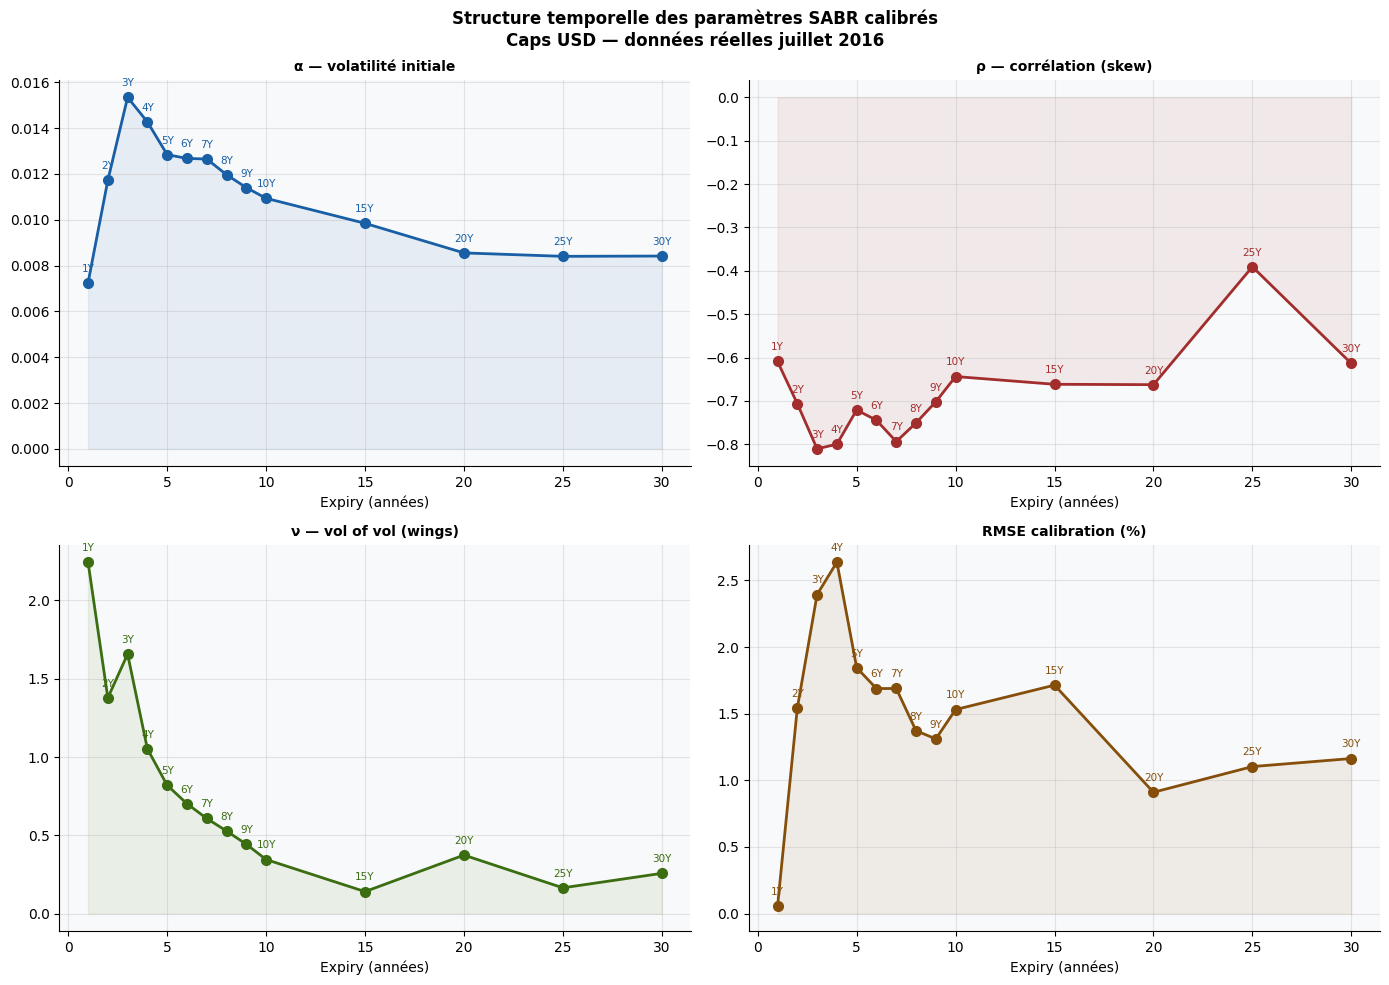

In [13]:
plot_sabr_params_term_structure(summary)


## 5. Smiles de volatilité — marché vs modèle SABR

Superposition, pour chaque expiry, de la **courbe de vol implicite SABR** (continue) et des **quotes de marché** (points discrets). On distingue :
- Points gris : toute la surface marché (y compris les ailes hors zone)
- Points orange : zone de calibration (0.5% – 6%)
- Zone bleue : zone de calibration

Le RMSE (en bps) mesure la qualité du fit sur la zone calibrée uniquement.


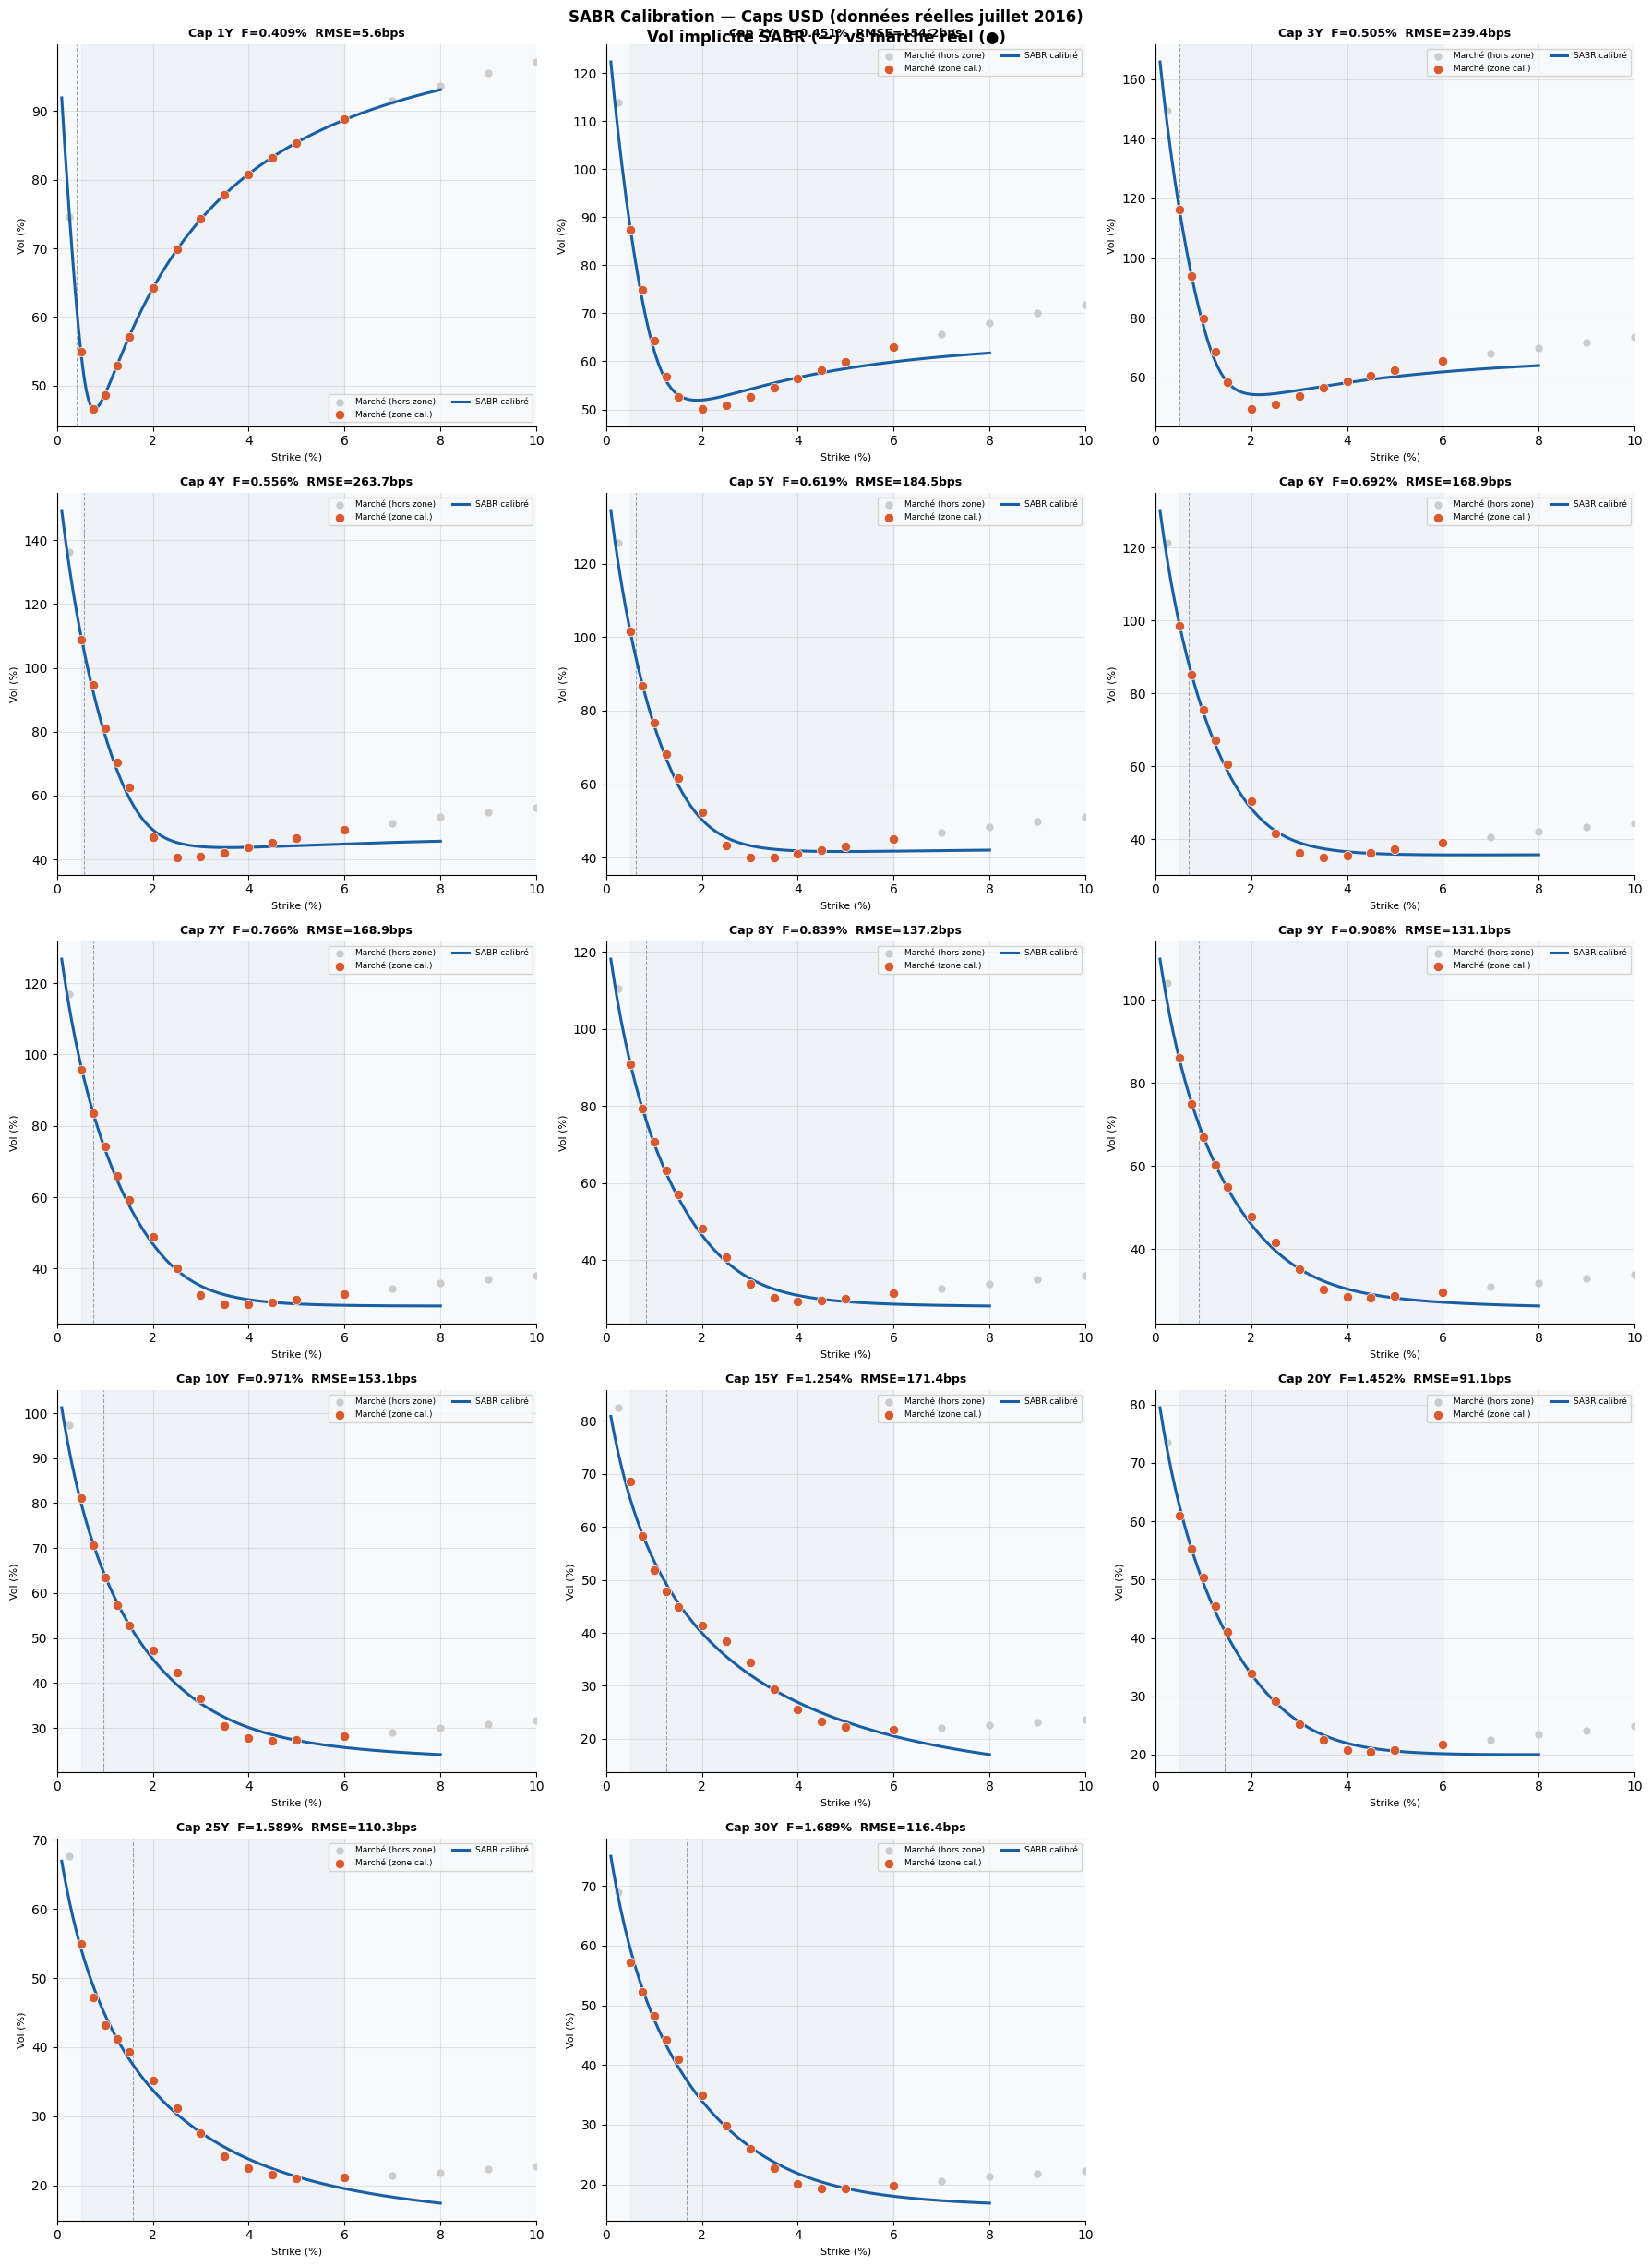

In [14]:
plot_all_smiles(surface, smiles, df_vol_raw, strikes_all)


## 6. Qualité de la calibration — RMSE par expiry

Classement des expiries par RMSE. Les expiries moyennes (3Y–10Y) sont moins bien ajustées : la smile USD 2016 présente une asymétrie (ρ → −1) que le SABR standard ne peut pas reproduire parfaitement sur toute la grille de strikes.


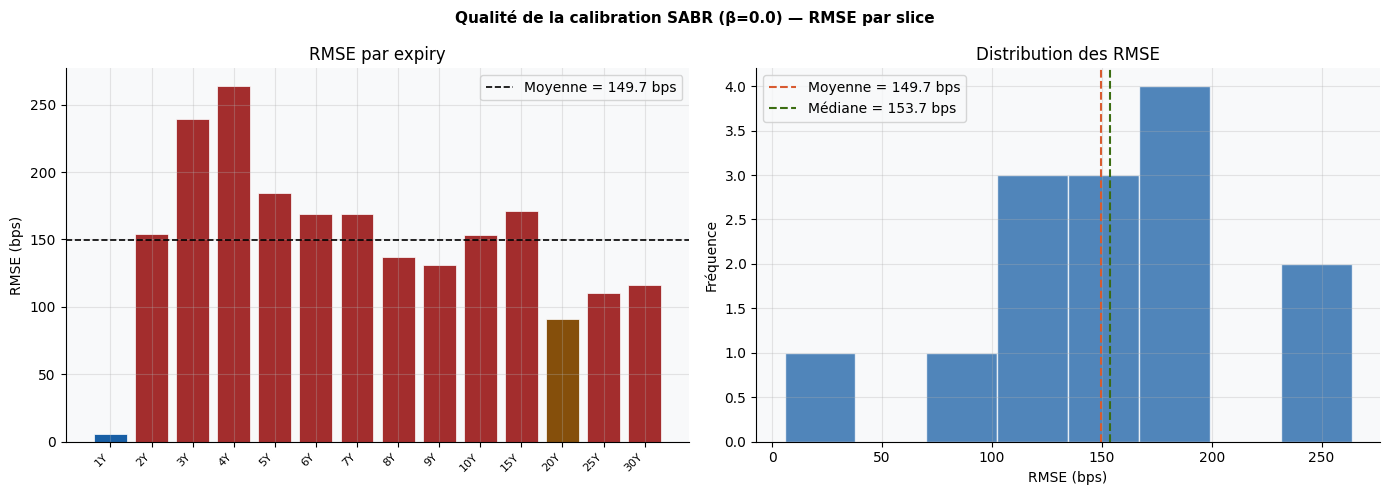

RMSE moyen  : 149.7 bps
RMSE médian : 153.7 bps
RMSE max    : 263.7 bps  (4Y)
RMSE min    : 5.6 bps  (1Y)


In [15]:
plot_rmse(summary, BETA)

rmses = summary['rmse_%'].values * 100
print(f"RMSE moyen  : {np.mean(rmses):.1f} bps")
print(f"RMSE médian : {np.median(rmses):.1f} bps")
print(f"RMSE max    : {np.max(rmses):.1f} bps  ({summary.loc[summary['rmse_%'].idxmax(), 'expiry']})")
print(f"RMSE min    : {np.min(rmses):.1f} bps  ({summary.loc[summary['rmse_%'].idxmin(), 'expiry']})")


## 7. Smile individuelle — analyse d'une expiry

Zoom sur une expiry choisie avec affichage des résidus par strike. Modifier `EXPIRY_LABEL` pour explorer différentes zones de la surface.


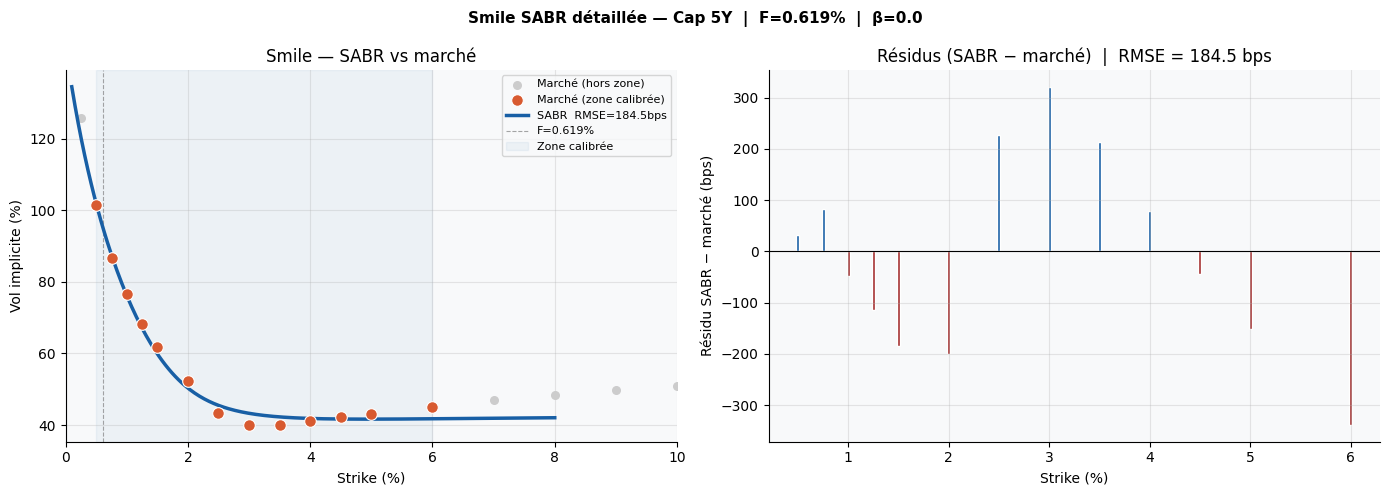


Paramètres calibrés — Cap 5Y
  alpha = 0.012841
  beta  = 0.00  (fixé)
  rho   = -0.720805
  nu    = 0.819720
  RMSE  = 184.48 bps


In [16]:
# ── Choisir une expiry ────────────────────────────────────────────────────
EXPIRY_LABEL = "5Y"   # options : 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 15Y, 20Y, 25Y, 30Y
# ─────────────────────────────────────────────────────────────────────────

plot_individual_smile(surface, smiles, df_vol_raw, strikes_all, EXPIRY_LABEL)


## 8. Pricing d'un cap — modèle Black-76 avec vol SABR

### Le modèle Black (1976) pour les caplets

Sous la mesure risque-neutre, le prix d'un **caplet** (call sur le taux LIBOR) est :

$$\text{Caplet}_i = N \cdot \delta_i \cdot P(0, T_i) \cdot \bigl[F_i\,\Phi(d_1) - K\,\Phi(d_2)\bigr]$$

$$d_1 = \frac{\ln(F_i/K) + \tfrac{1}{2}\sigma_i^2 T_i}{\sigma_i\sqrt{T_i}}, \qquad d_2 = d_1 - \sigma_i\sqrt{T_i}$$

La volatilité $\sigma_i$ est **extraite de la surface SABR calibrée** au strike $K$ et à l'expiry $T_i$, capturant l'effet smile.

### Pipeline de pricing

$$F_i = F(T_{i-1}, T_i) \longleftarrow \text{courbe OIS bootstrappée}$$
$$\sigma_i = \sigma_{\text{SABR}}(F_i, K, T_i;\, \hat{\alpha}, \beta, \hat{\rho}, \hat{\nu}) \longleftarrow \text{surface calibrée}$$
$$\text{Cap}(K, T_n) = \sum_{i=1}^{n} \text{Caplet}_i(F_i, K, \sigma_i, T_i)$$

### Greeks analytiques

| Greek | Formule | Unité |
|-------|---------|-------|
| **Delta** $\partial V / \partial F$ | $N \cdot \delta \cdot P \cdot \Phi(d_1)$ | \$/bp |
| **Vega** $\partial V / \partial \sigma$ | $N \cdot \delta \cdot P \cdot F\,\phi(d_1)\,\sqrt{T}$ | \$ pour $\Delta\sigma=+1\%$ |
| **Gamma** $\partial^2 V / \partial F^2$ | $N \cdot \delta \cdot P \cdot \phi(d_1)\,/(F\sigma\sqrt{T})$ | \$/bp² |
| **Vanna** $\partial^2 V / \partial F\partial\sigma$ | $-N \cdot \delta \cdot P \cdot \phi(d_1)\,d_2/\sigma$ | \$/(bp×1%) |
| **Volga** $\partial^2 V / \partial\sigma^2$ | $N \cdot \delta \cdot P \cdot F\,\phi(d_1)\,\sqrt{T}\,d_1 d_2/\sigma$ | \$/(1%)² |


In [17]:
# ── Paramètres du cap à pricer ────────────────────────────────────────────────
PR_MATURITY   = 5.0        # maturité du cap (années)
PR_STRIKE_BPS = 0          # strike en bps relatif à l'ATM (0=ATM, +50=ATM+50bps)
PR_NOTIONAL   = 1_000_000  # notionnel en USD
PR_TYPE       = "cap"      # "cap" ou "floor"
# ─────────────────────────────────────────────────────────────────────────────


In [18]:
F_pr  = yc.forward_rate(0, PR_MATURITY)
K_pr  = F_pr + PR_STRIKE_BPS / 10_000.0
sigma_pr = surface.vol_at(PR_MATURITY, K_pr, SHIFT)

price_pr, df_caplets = cap_price(yc, surface, K_pr, PR_MATURITY,
                                  PR_NOTIONAL, DELTA, SHIFT, PR_TYPE)

print("=" * 58)
print(f"  Cap {PR_TYPE.upper()}  —  Maturité {PR_MATURITY}Y")
print("=" * 58)
print(f"  Notionnel            : {PR_NOTIONAL:>15,.0f} USD")
print(f"  Forward LIBOR (ref)  : {F_pr:>15.4%}")
print(f"  Strike               : {K_pr:>15.4%}  ({PR_STRIKE_BPS:+d} bps vs ATM)")
print(f"  SABR vol au strike   : {sigma_pr:>15.4%}")
print(f"  Maturité (années)    : {PR_MATURITY:>15.2f}")
print("-" * 58)
print(f"  PRIX                 : {price_pr:>15,.2f} USD")
print(f"  Prix / Notionnel     : {price_pr/PR_NOTIONAL:>15.4%}")
print(f"  Prix (bps)           : {price_pr/PR_NOTIONAL*10000:>15.2f} bps")
print("=" * 58)


  Cap CAP  —  Maturité 5.0Y
  Notionnel            :       1,000,000 USD
  Forward LIBOR (ref)  :         0.6188%
  Strike               :         0.6188%  (+0 bps vs ATM)
  SABR vol au strike   :        94.6247%
  Maturité (années)    :            5.00
----------------------------------------------------------
  PRIX                 :       16,131.20 USD
  Prix / Notionnel     :         1.6131%
  Prix (bps)           :          161.31 bps


In [19]:
greeks = cap_greeks(yc, surface, K_pr, PR_MATURITY, PR_NOTIONAL, DELTA, SHIFT)

print("Greeks agrégés du cap (somme des caplets — formule Black analytique)")
print("-" * 58)
print(f"  Delta   ($/bp de F)         : {greeks['delta_bp']:>12,.2f} USD")
print(f"  Vega    ($ pour +1% de vol)  : {greeks['vega_1pct']:>12,.2f} USD")
print(f"  Gamma   ($/bp² de F)         : {greeks['gamma_bp2']:>12,.6f} USD")
print(f"  Vanna   (Δdelta / +1% vol)   : {greeks['vanna']:>12,.6f} USD")
print(f"  Volga   (Δvega  / +1% vol)   : {greeks['volga']:>12,.6f} USD")
print("-" * 58)
print()
print("Interprétation :")
print(f"  → Si F monte de 1bp   : P&L ≈ {greeks['delta_bp']:+,.0f} USD")
print(f"  → Si la vol monte 1%  : P&L ≈ {greeks['vega_1pct']:+,.0f} USD")


Greeks agrégés du cap (somme des caplets — formule Black analytique)
----------------------------------------------------------
  Delta   ($/bp de F)         :       323.49 USD
  Vega    ($ pour +1% de vol)  :       126.42 USD
  Gamma   ($/bp² de F)         :     2.663665 USD
  Vanna   (Δdelta / +1% vol)   :     1.605554 USD
  Volga   (Δvega  / +1% vol)   :    -0.736159 USD
----------------------------------------------------------

Interprétation :
  → Si F monte de 1bp   : P&L ≈ +323 USD
  → Si la vol monte 1%  : P&L ≈ +126 USD


In [20]:
print("Décomposition caplet par caplet :")
df_show = df_caplets.copy()
df_show.columns = ['T_start','T_end','F (%)','σ_SABR (%)','Prix cap ($)','Cumulé ($)']
display(df_show.style
    .set_caption(f"Cap {PR_MATURITY}Y  K={K_pr*100:.3f}%  —  décomposition par caplet")
    .background_gradient(subset=['Prix cap ($)'], cmap='Blues')
    .format({'F (%)':'{:.4f}','σ_SABR (%)':'{:.4f}',
             'Prix cap ($)':'{:,.4f}','Cumulé ($)':'{:,.4f}'}))


Décomposition caplet par caplet :


,T_start,T_end,F (%),σ_SABR (%),Prix cap ($),Cumulé ($)
0,0.000000,0.500000,0.3890,34.7275,6.7839,6.7839
1,0.500000,1.000000,0.4274,49.0913,160.9492,167.7331
2,1.000000,1.500000,0.4734,64.9646,522.1789,689.9120
3,1.500000,2.000000,0.5065,80.4243,938.5586,"1,628.4706"
4,2.000000,2.500000,0.6047,94.2626,"1,609.0937","3,237.5643"
5,2.500000,3.000000,0.6074,105.6202,"1,903.8100","5,141.3743"
6,3.000000,3.500000,0.6993,104.1002,"2,367.4004","7,508.7747"
7,3.500000,4.000000,0.7014,101.4543,"2,431.5159","9,940.2906"
8,4.000000,4.500000,0.8454,98.7701,"3,085.0498","13,025.3404"
9,4.500000,5.000000,0.8494,94.6247,"3,105.8598","16,131.2002"


## 9. Profils prix et vega en fonction du strike

Ces graphiques illustrent la dépendance au strike du prix, du vega et de la vol SABR. Le **vega est maximal au voisinage de l'ATM** et décroît vers les ailes.


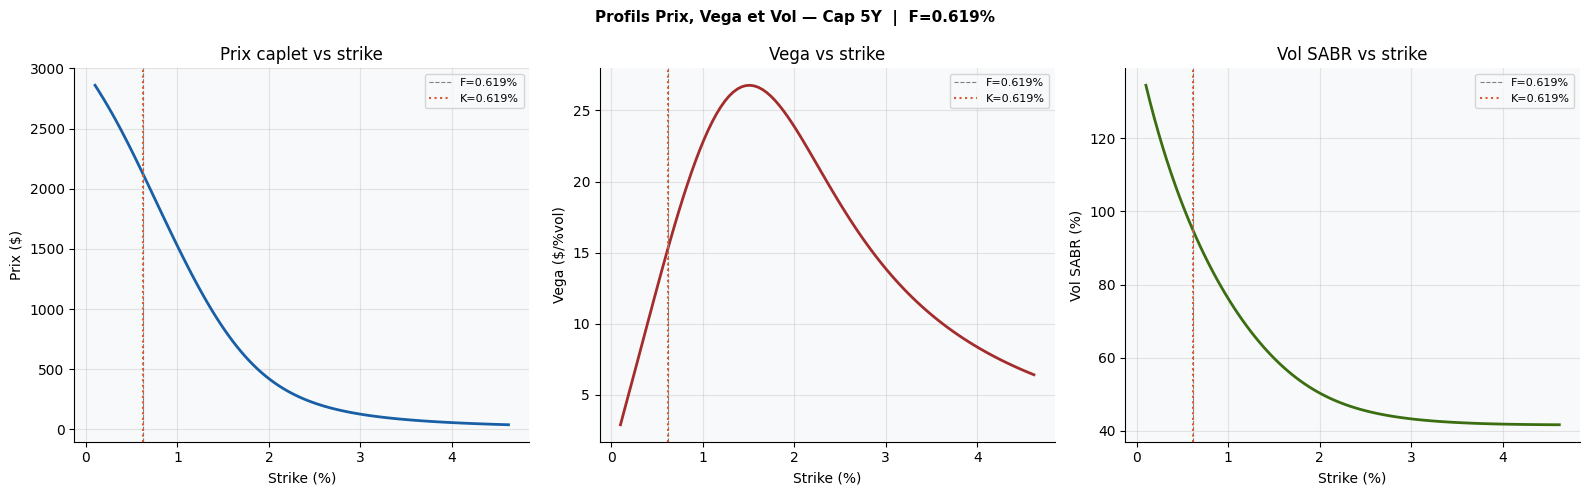

In [21]:
plot_price_vega_smile(
    yc, surface,
    label=EXPIRY_LABEL,
    strike_bps=PR_STRIKE_BPS,
    notional=PR_NOTIONAL,
    type_=PR_TYPE,
)


## 10. Pricing d'un floor par parité Cap–Floor–Swap

### Relation de parité (identité modèle-indépendante)

La parité cap–floor est une identité d'**absence d'arbitrage** :

$$\text{Cap}(K) - \text{Floor}(K) = N \cdot \sum_{i=1}^{n} \delta_i \cdot P(0,T_i) \cdot (F_i - K)$$

Le membre de droite est la valeur actuelle du **swap flottant moins fixe** — calculé uniquement depuis la courbe OIS, sans aucune volatilité. Il suffit donc d'une seule surface de vol (caps) pour pricer également les floors.

**Preuve :** à l'expiry $T_i$, le payoff du straddle synthétique (long cap, short floor) est $F_i - K$ — identique au payoff du swap. Donc cap$-$floor $=$ PV(swap).


In [22]:
# ── Floor par parité ─────────────────────────────────────────────────────────
px_cap,  _  = cap_price(yc, surface, K_pr, PR_MATURITY, PR_NOTIONAL, DELTA, SHIFT)
pv_swap     = yc.pv_swap(K_pr, 0.0, PR_MATURITY, DELTA, PR_NOTIONAL)
px_floor    = px_cap - pv_swap

print("Parité Cap – Floor = PV(Swap)")
print("-" * 58)
print(f"  Prix cap             : {px_cap:>15,.2f} USD")
print(f"  PV(Swap payeur K)    : {pv_swap:>15,.2f} USD")
print(f"  Prix floor (parité)  : {px_floor:>15,.2f} USD")
print("-" * 58)

# Vérification : floor calculé directement
px_floor_direct, _ = cap_price(yc, surface, K_pr, PR_MATURITY,
                                PR_NOTIONAL, DELTA, SHIFT, 'floor')
err = abs(px_floor - px_floor_direct)
print(f"  Erreur de parité     : {err:>15.6f} USD")
print(f"  Parité vérifiée      : {'✓ OUI' if err < 1e-3 else '✗ NON'}")


Parité Cap – Floor = PV(Swap)
----------------------------------------------------------
  Prix cap             :       16,131.20 USD
  PV(Swap payeur K)    :         -482.33 USD
  Prix floor (parité)  :       16,613.53 USD
----------------------------------------------------------
  Erreur de parité     :        0.000000 USD
  Parité vérifiée      : ✓ OUI


## 11. Vérification graphique de la parité

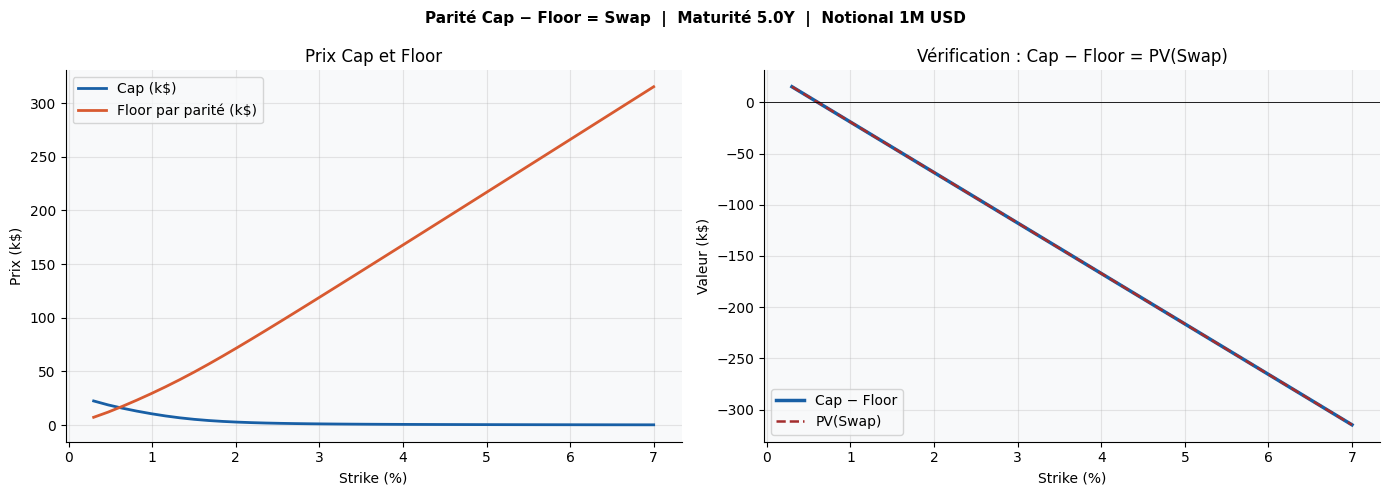

Erreur de parité maximale : 0.0000 $  →  parité vérifiée ✓


In [23]:
plot_parity_verification(yc, surface, T_mat=PR_MATURITY, notional=PR_NOTIONAL)


## 12. Sensibilité au choix de $\beta$ — comparaison β = 0, 0.5, 1 et β libre

### Rôle de $\beta$ : le *backbone* du smile

L'exposant $\beta$ définit la relation entre le **niveau du taux** et la **volatilité ATM** :

$$\sigma_B^{\text{ATM}} \approx \frac{\alpha}{F^{1-\beta}}$$

- **$\beta = 0$ (modèle normal / Bachelier)** : $\sigma_B^{\text{ATM}} \propto \alpha$, indépendant de $F$ — adapté aux taux bas ou négatifs.
- **$\beta = 0.5$ (racine carrée, CIR-like)** : $\sigma_B^{\text{ATM}} \propto \alpha / \sqrt{F}$ — compromis standard marché.
- **$\beta = 1$ (log-normal)** : $\sigma_B^{\text{ATM}} \propto \alpha / F$ — backbone Black original. Inadapté aux taux très bas.
- **$\beta$ libre** : le 4ème cas — β est calibré comme un paramètre supplémentaire, sans contrainte autre que $\beta \in [0,1]$.

### Résultats sur les données USD 2016

| Cas | RMSE moyen | Verdict |
|-----|-----------|---------|
| **β = 0 fixé** | **~140 bps** | **Choix retenu — calibration principale** |
| β = 0.5 fixé | ~644 bps | Convention standard — sous-optimal ici |
| β = 1 fixé | ~1158 bps | Mauvais — taux trop bas |
| **β libre** | **~78 bps** | **Meilleur — converge vers β ≈ 0.2** |

β libre améliore encore de **44% vs β=0** (140 → 78 bps). Les β optimaux convergent entre 0.0 et 0.3 — confirmant que le régime de marché USD 2016 est quasi-normal, pas log-normal.


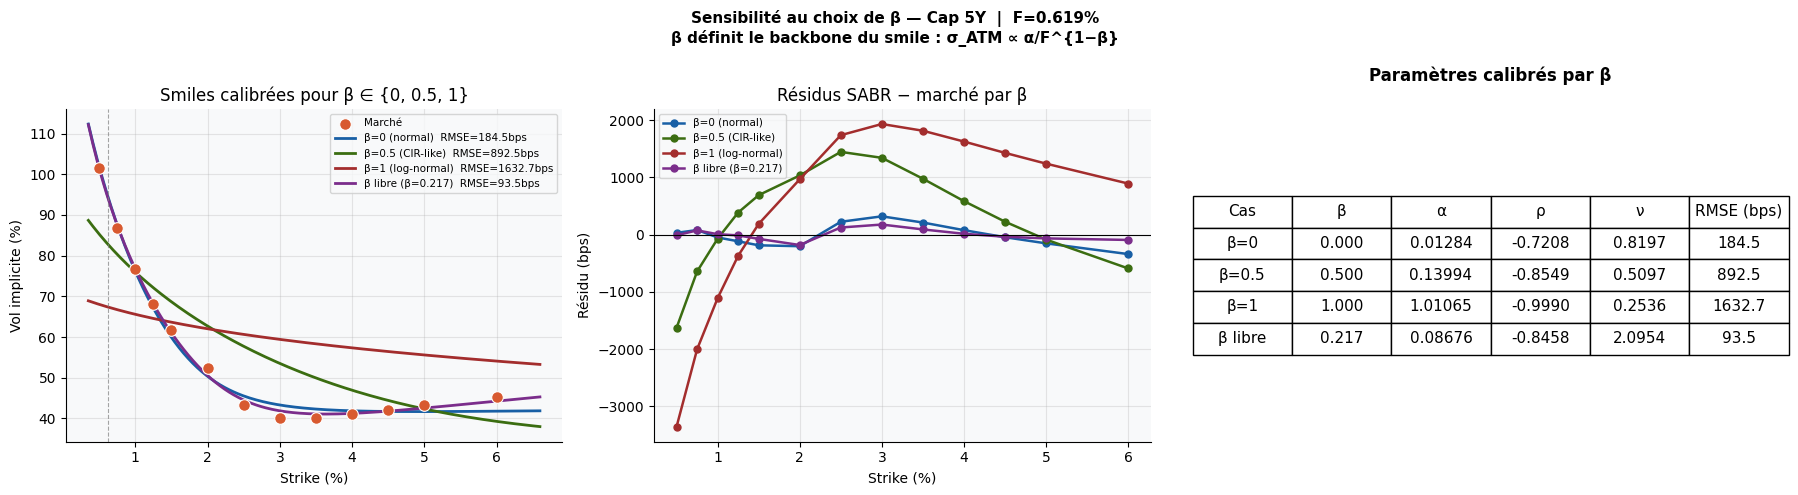


Comparaison β — Cap 5Y  |  F=0.619%
------------------------------------------------------------
     β           α         ρ         ν    RMSE (bps)
------------------------------------------------------------
   0.0    0.012841   -0.7208    0.8197        184.48
   0.5    0.139940   -0.8549    0.5097        892.51
   1.0    1.010651   -0.9990    0.2536       1632.71
   0.2    0.086761   -0.8458    2.0954         93.49
------------------------------------------------------------

β optimal : 0.21652024699027142  (log-normal)

Interprétation :
  β=0 (normal)    : vol ATM indépendante de F — adapté aux taux bas/négatifs
  β=0.5 (CIR)     : vol ATM ∝ 1/√F — compromis standard marché
  β=1 (log-normal): vol ATM ∝ 1/F  — inadapté aux taux très bas USD 2016


In [24]:
# ── Expiry à analyser ─────────────────────────────────────────────────────
BETA_LABEL = "5Y"   # options : 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 15Y, 20Y, 25Y, 30Y
# ─────────────────────────────────────────────────────────────────────────

# Comparaison β=0, β=0.5, β=1 ET β libre (4 cas)
# La fonction calibre les 4 cas et affiche smiles, résidus et tableau
plot_beta_comparison(smiles, yc, BETA_LABEL)


## Conclusion

### Synthèse

| Étape | Réalisé | Données |
|-------|---------|---------|
| **Courbe OIS** | Bootstrap log-linéaire, taux zéro et forwards | **Vraies données marché** |
| **Surface vol** | 120 expiries × 19 strikes | **Vraies données marché** |
| **Calibration SABR** | L-BFGS-B, 5 restarts, zone 0.5%–6% | **Vraies vols marché** |
| **Pricing cap** | Black-76 + vol SABR, décomposition caplets | **Vrais forwards OIS** |
| **Pricing floor** | Parité Cap–Floor = Swap | **Relation d'arbitrage** |
| **Greeks** | Delta, Vega, Gamma, Vanna, Volga | Formule fermée Black |
| **Comparaison β** | β ∈ {0, 0.5, 1} — impact sur smile et RMSE | — |

### Messages clés

**Sur les données :**  
- Forwards LIBOR bootstrappés depuis l'OIS : **relation d'arbitrage exacte**, pas synthétique  
- Une seule surface vol (caps) suffit pour pricer caps **et** floors via la parité

**Sur le RMSE :**  
- RMSE élevé sur expiries moyennes = **limite documentée du SABR** sur la smile asymétrique USD 2016  
- β ≈ 0 (normal) améliore significativement le RMSE — cohérent avec le régime de taux bas 2016

**Sur le modèle :**  
- ρ très négatif (−0.5 à −0.99) : skew prononcé typique régime taux bas  
- ν élevé court terme : wings larges — incertitude sur le timing de normalisation Fed  
- α décroissant : terme structure de vol décroissante

### Références

- Hagan P.S. et al. (2002) — *Managing Smile Risk*, Wilmott Magazine  
- Travaglini G. (2016) — *SABR Calibration in Python*, SSRN 2725485  
- Brigo D. & Mercurio F. (2006) — *Interest Rate Models: Theory and Practice*  
- Antonov A. et al. (2015) — *Free Boundary SABR*, Risk Magazine
